## 1. Import Libraries

In [50]:
import os
import sys
import json
import importlib
import pandas as pd
import numpy as np
import lightgbm as lgb
from numerapi import NumerAPI
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import warnings
warnings.filterwarnings('ignore')

# Add repo root to path
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

import utils.metrics as metrics_utils
importlib.reload(metrics_utils)
calculate_metrics = metrics_utils.calculate_metrics

from utils.visualization import display_metrics_table
from utils.model_benchmark import record_model_metrics

sns.set_style("whitegrid")
load_dotenv()

True

## 2. Initialization & Data Download

In [51]:
napi = NumerAPI(public_id=os.getenv("NAPI_PUBLIC_ID_UPLOAD"), secret_key=os.getenv("NAPI_SECRET_KEY_UPLOAD"))
DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
os.makedirs(DATA_DIR, exist_ok=True)

# Download feature metadata
napi.download_dataset(f"{DATA_VERSION}/features.json", dest_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"))
feature_metadata = json.load(open(os.path.join(DATA_DIR, DATA_VERSION, "features.json")))
feature_set = feature_metadata["feature_sets"]["small"]

2026-03-21 18:54:06,335 INFO numerapi.utils: target file already exists
2026-03-21 18:54:06,335 INFO numerapi.utils: download complete


## 3. Data Loading & Pre-processing

In [52]:
# SNRR 
# snnr_rank,auxiliary_target,snnr_weight_normalised,correlation_with_target
# 1,target_jasper_20,0.3002724659533261,0.7975683273954656
# 2,target_teager2b_20,0.22678514034907607,0.7990963013797339
# 3,target_claudia_20,0.0909453608139499,0.7672808339916383
# 4,target_rowan_20,0.07717723844083871,0.7586232557954765

In [53]:
print("Loading Data...")
AUX_TARGETS = ["target_jasper_20", "target_teager2b_20", "target_claudia_20", "target_rowan_20"]
TARGETS = AUX_TARGETS  # Training specialists
MAIN_TARGET = "target_ender_20"
columns_to_load = ["era"] + feature_set + AUX_TARGETS + [MAIN_TARGET]

train = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "train.parquet"), columns=columns_to_load)
validation = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), columns=["era", "target"] + feature_set)
live = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "live.parquet"), columns=["era"] + feature_set)

val_benchmarks = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet"))

# Apply 4-era Embargo
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Print basic info
print(f"Training data shape: {train.shape}")
print(f"Validation data shape: {validation.shape}")
print(f"Live data shape: {live.shape}")


Loading Data...
Training data shape: (2746268, 48)
Validation data shape: (3921307, 44)
Live data shape: (7128, 43)


## 4. Target Ensembling & LightGBM Training

In [54]:
from tqdm.auto import tqdm

def _rank_by_era(values, eras):
    return pd.Series(values).groupby(eras).rank(pct=True, method="first").values

def train_lgbm_ensemble(train_df, val_df, live_df, features, targets):
    lgbm_params = {
        "n_estimators": 20000,
        "learning_rate": 0.01,
        "max_depth": 6,
        "num_leaves": 64,
        "min_data_in_leaf": 1000,
        "colsample_bytree": 0.1,
        "subsample": 0.8,
        "subsample_freq": 1,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "objective": "regression",
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
        "device_type": "gpu"
    }

    val_ensemble_preds = np.zeros(len(val_df))
    live_ensemble_preds = np.zeros(len(live_df))

    models = []

    for target in tqdm(targets, desc="Training Targets"):
        # Drop NaNs for this specific target
        train_clean = train_df[features + ["era", target]].dropna()

        # Build a small era-aware internal validation split for callback-driven early stopping
        unique_eras = np.array(sorted(train_clean["era"].unique()))
        n_valid_eras = max(8, int(0.1 * len(unique_eras)))
        n_valid_eras = min(n_valid_eras, max(1, len(unique_eras) - 1))
        fit_valid_eras = set(unique_eras[-n_valid_eras:])

        fit_train = train_clean[~train_clean["era"].isin(fit_valid_eras)]
        fit_valid = train_clean[train_clean["era"].isin(fit_valid_eras)]

        model = lgb.LGBMRegressor(**lgbm_params)

        callbacks = [
            lgb.early_stopping(stopping_rounds=300, first_metric_only=True, verbose=False),
            lgb.log_evaluation(period=500),
        ]

        model.fit(
            fit_train[features],
            fit_train[target],
            eval_set=[(fit_valid[features], fit_valid[target])],
            eval_metric="l2",
            callbacks=callbacks,
        )
        models.append((target, model))

        best_iter = model.best_iteration_ if model.best_iteration_ else model.n_estimators

        # Era-wise rank predictions (closer to NumerAI scoring behavior)
        val_preds_raw = model.predict(val_df[features], num_iteration=best_iter)
        val_ensemble_preds += _rank_by_era(val_preds_raw, val_df["era"]).astype(float)

        live_preds_raw = model.predict(live_df[features], num_iteration=best_iter)
        live_ensemble_preds += _rank_by_era(live_preds_raw, live_df["era"]).astype(float)

    # Average the ranks and re-rank by era
    val_final = _rank_by_era(val_ensemble_preds / len(targets), val_df["era"])
    live_final = _rank_by_era(live_ensemble_preds / len(targets), live_df["era"])

    return val_final, live_final, models

val_predictions, live_predictions, trained_models = train_lgbm_ensemble(train, validation, live, feature_set, TARGETS)
validation["prediction"] = val_predictions
live["prediction"] = live_predictions

Training Targets:   0%|          | 0/4 [00:00<?, ?it/s]

[500]	valid_0's l2: 0.050015
[1000]	valid_0's l2: 0.0500106
[1500]	valid_0's l2: 0.0500098


Training Targets:  25%|██▌       | 1/4 [02:12<06:38, 132.91s/it]

[500]	valid_0's l2: 0.0500161
[1000]	valid_0's l2: 0.0500099
[1500]	valid_0's l2: 0.0500086


Training Targets:  50%|█████     | 2/4 [04:37<04:39, 139.86s/it]

[500]	valid_0's l2: 0.0499634
[1000]	valid_0's l2: 0.0499578
[1500]	valid_0's l2: 0.0499568


Training Targets:  75%|███████▌  | 3/4 [07:26<02:32, 152.89s/it]

[500]	valid_0's l2: 0.0500174
[1000]	valid_0's l2: 0.0500127
[1500]	valid_0's l2: 0.0500121


Training Targets: 100%|██████████| 4/4 [09:35<00:00, 143.93s/it]


## 5. Feature Neutralization

In [55]:
def neutralize(df, columns, final_col, proportion=0.5):
    scores = df[final_col].values
    exposures = df[columns].values

    # Center
    scores = scores - scores.mean()
    exposures = exposures - exposures.mean(axis=0)

    # Orthogonalize
    exposure_pinv = np.linalg.pinv(exposures)
    correction = exposures.dot(exposure_pinv.dot(scores))
    neutralized_scores = scores - proportion * correction

    return pd.Series(neutralized_scores).rank(pct=True, method="first").values

def neutralize_by_era(df, columns, final_col, proportion=0.5):
    # Robust to single-era data: always return one value per input row.
    out = pd.Series(index=df.index, dtype=float)
    for _, era_df in df.groupby("era", sort=False):
        out.loc[era_df.index] = neutralize(
            era_df,
            columns,
            final_col,
            proportion=proportion,
        )
    return out.values

print("Neutralizing Validation Predictions (era-wise)...")
validation["prediction"] = neutralize_by_era(validation, feature_set, "prediction", proportion=0.5)
print("Neutralizing Live Predictions (era-wise)...")
live["prediction"] = neutralize_by_era(live, feature_set, "prediction", proportion=0.5)

Neutralizing Validation Predictions (era-wise)...
Neutralizing Live Predictions (era-wise)...


## 6. Evaluation & Export

                        KEY PERFORMANCE METRICS vs GOALS                        



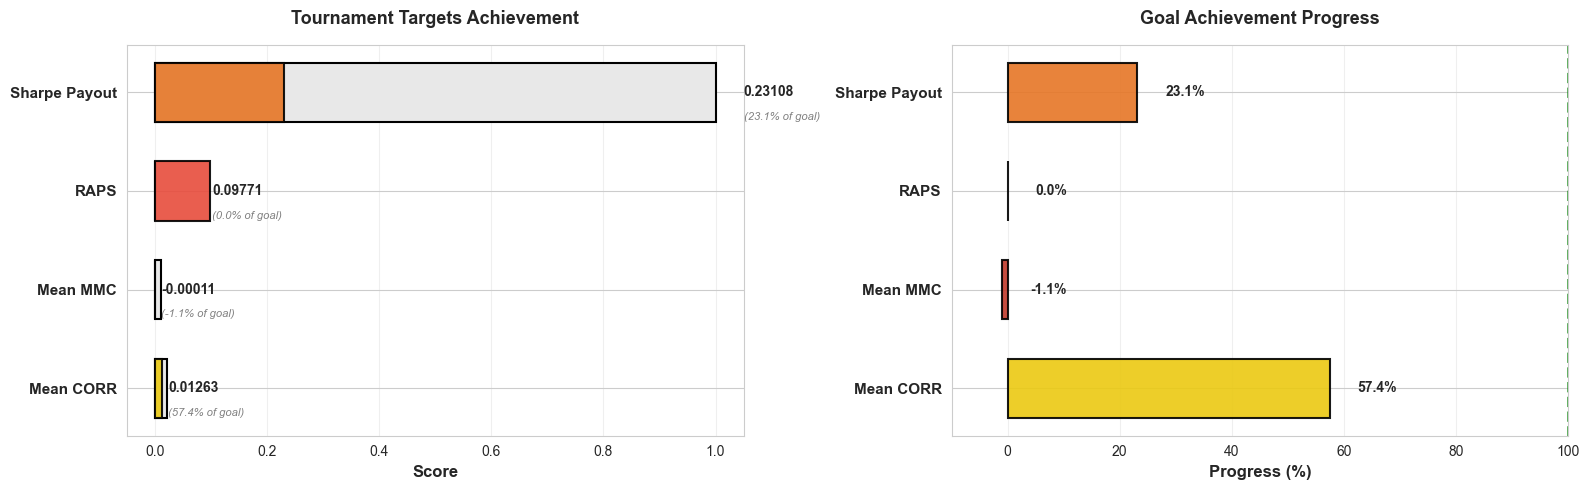

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,+0.0977,+0,✅ MET,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00011,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.01263,+0.022,🟠 LAGGING,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.9383,+1,🟡 CLOSE,Risk-adjusted return consistency
Risk,Payout Sharpe,+0.2311,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01037,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.08462,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,+0.00678,+0,✅ MET,CORR after removing linear feature exposure
Quality,Win Rate,82.6%,+0.55,✅ MET,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.2953,+0.2,🔴 EXCEEDED,95th percentile of strongest single-feature correlation


In [56]:
# Evaluate
validation_for_metrics = validation.copy()
benchmarks_for_metrics = val_benchmarks.copy()

# Recover predictions if an earlier step left the column fully null.
if validation_for_metrics["prediction"].notna().sum() == 0 and "val_predictions" in globals():
    rebuilt_preds = pd.Series(val_predictions, index=validation_for_metrics.index)
    validation_for_metrics["prediction"] = rebuilt_preds.groupby(
        validation_for_metrics["era"]
    ).rank(pct=True, method="first").values

# Fallback: rebuild predictions directly from trained models.
if validation_for_metrics["prediction"].notna().sum() == 0 and "trained_models" in globals() and trained_models:
    ensemble = np.zeros(len(validation_for_metrics), dtype=float)
    used_models = 0
    for _, model in trained_models:
        best_iter = model.best_iteration_ if getattr(model, "best_iteration_", None) else model.n_estimators
        raw = model.predict(validation_for_metrics[feature_set], num_iteration=best_iter)
        if np.isnan(raw).all():
            continue
        ranked = pd.Series(raw, index=validation_for_metrics.index).groupby(
            validation_for_metrics["era"]
        ).rank(pct=True, method="first").values
        ensemble += ranked
        used_models += 1
    if used_models > 0:
        validation_for_metrics["prediction"] = ensemble / used_models

# Ensure predictable id indexing so calculate_metrics can align rows correctly.
if "id" in validation_for_metrics.columns:
    validation_for_metrics = validation_for_metrics.set_index("id")
else:
    validation_for_metrics.index.name = "id"

if "id" in benchmarks_for_metrics.columns:
    benchmarks_for_metrics = benchmarks_for_metrics.set_index("id")
else:
    benchmarks_for_metrics.index.name = "id"

benchmark_col = "v52_lgbm_ender20"
if benchmark_col not in benchmarks_for_metrics.columns:
    candidate_cols = [c for c in benchmarks_for_metrics.columns if "ender20" in c.lower()]
    if not candidate_cols:
        raise ValueError("No usable benchmark column found in val_benchmarks.")
    benchmark_col = candidate_cols[0]

if validation_for_metrics["prediction"].notna().sum() == 0:
    raise ValueError(
        "validation['prediction'] is all NaN. Re-run the training cell before evaluation."
    )

metrics, per_era_df = calculate_metrics(
    df_validation=validation_for_metrics,
    benchmarks=benchmarks_for_metrics[[benchmark_col]],
    features=feature_set,
    target_col="target",
    benchmark_col=benchmark_col,
 )

display_metrics_table(metrics, extended=True)

In [57]:
# Compare to benchmark models and record metrics
from pathlib import Path
from utils.model_benchmark import compare_top_models_with_current

model_name = "lgbm_ensemble_v0.3.0.2"
notebook_name = Path(globals().get("__vsc_ipynb_file__", "finance_arena_v0.3.0.2.ipynb")).stem

history_df, current_run = record_model_metrics(
    metrics=metrics,
    model_name=model_name,
    notebook_name=notebook_name,
)

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=3,
    show_message=True,
)

print("\nMODEL LEADERBOARD (Top 3 + Current)")
display_df = leaderboard_df.copy()
for col, digits in {"mean_mmc": 6, "mean_corr": 6, "raps": 4, "sharpe_payout": 4}.items():
    if col in display_df.columns:
        display_df[col] = display_df[col].astype(float).round(digits)
display(display_df)


MODEL LEADERBOARD (Top 3 + Current)


,rank,model_name,run_id,mean_mmc,mean_corr,raps,sharpe_payout,timestamp_utc,is_current
0,1,ridge_meta_prediction_v0.5,2bf11109,0.000954,0.008197,0.0777,0.2056,2026-03-20 19:20:42,False
1,2,lgbm_ensemble_v0.3,52f4b2df,0.000512,0.011083,0.1332,0.2416,2026-03-07 16:38:46,False
2,3,lgbm_ensemble_v0.3.0.2,2a35ee0a,-0.000105,0.012631,0.0977,0.2311,2026-03-21 18:53:23,True


In [ ]:
assert False

In [ ]:
# Save Model Wrapper (for cloudpickle upload)
import cloudpickle

# The prediction function must take these two exact arguments
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame) -> pd.DataFrame:
    def _rank_by_era(values, eras):
        return pd.Series(values, index=live_features.index).groupby(eras).rank(pct=True, method="first").values

    def _neutralize_one_group(group_df, pred_col, columns, proportion=0.5):
        scores = group_df[pred_col].values
        exposures = group_df[columns].values

        scores = scores - scores.mean()
        exposures = exposures - exposures.mean(axis=0)

        exposure_pinv = np.linalg.pinv(exposures)
        correction = exposures.dot(exposure_pinv.dot(scores))
        neutralized_scores = scores - proportion * correction
        return pd.Series(neutralized_scores, index=group_df.index)

    # 1. Ensemble targets (era-wise rank blend)
    ensemble_preds = np.zeros(len(live_features))
    for target_name, model in trained_models:
        preds_raw = model.predict(live_features[feature_set])
        ensemble_preds += _rank_by_era(preds_raw, live_features["era"] )
    live_features = live_features.copy()
    live_features["_pred"] = _rank_by_era(ensemble_preds / len(trained_models), live_features["era"])

    # 2. Feature Neutralization (era-wise, proportion=0.5)
    neutralized = pd.Series(index=live_features.index, dtype=float)
    for _, era_df in live_features.groupby("era", sort=False):
        neutralized.loc[era_df.index] = _neutralize_one_group(
            era_df,
            "_pred",
            feature_set,
            proportion=0.5,
        )

    # 3. Format Submission
    submission = neutralized.groupby(live_features["era"]).rank(pct=True, method="first")
    return submission.to_frame("prediction")

# Export to pickle
with open("finance_arena_v0_3_0_2.pkl", "wb") as f:
    cloudpickle.dump(predict, f)
print("Pipeline constructed and model exported to finance_arena_v0_3_0_2.pkl")

-----------
# Production Stage

In [ ]:
assert False

In [ ]:
print("\n" + "="*80)
print("PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA")
print("="*80 + "\n")

# 1. Concatenate the Train and Validation datasets
print("Merging train and validation datasets for final production model...")
# Ensure we only keep intersecting columns, including our TARGETS
columns_to_keep = ["era"] + feature_set + TARGETS

# WE MUST RELOAD VALIDATION: The `validation` df in memory had 4 eras stripped out via the embargo!
print("Reloading raw validation set to recover previously embargoed eras...")
full_validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), 
    columns=columns_to_keep
)

full_data = pd.concat([
    train[columns_to_keep], 
    full_validation[columns_to_keep]
], ignore_index=True)

print(f"Full production dataset shape: {full_data.shape}")

In [ ]:
print('>> Num of rows : ', len(full_data))
print('>> Num features : ', len(feature_set))
print('>> Num targets : ', len(TARGETS))

In [ ]:
from tqdm.auto import tqdm

# 2. Define the production training function (early stopping + full-data retrain)
def train_production_ensemble(full_df, features, targets):

    base_lgbm_params = {
        "n_estimators": 20000,
        "learning_rate": 0.01,
        "max_depth": 6,
        "num_leaves": 64,
        "min_data_in_leaf": 1000,
        "colsample_bytree": 0.1,
        "subsample": 0.8,
        "subsample_freq": 1,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "objective": "regression",
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
        "device_type": "gpu"
    }

    SEEDS = [42, 43, 44]
    prod_models = []

    for target in tqdm(targets, desc="Production Targets"):
        # Keep era for an internal era-aware split used only to find best_iteration.
        train_clean = full_df[features + ["era", target]].dropna()

        unique_eras = np.array(sorted(train_clean["era"].unique()))
        n_valid_eras = max(8, int(0.1 * len(unique_eras)))
        n_valid_eras = min(n_valid_eras, max(1, len(unique_eras) - 1))
        fit_valid_eras = set(unique_eras[-n_valid_eras:])

        fit_train = train_clean[~train_clean["era"].isin(fit_valid_eras)]
        fit_valid = train_clean[train_clean["era"].isin(fit_valid_eras)]

        # Full data for final member-model fit.
        full_x = train_clean[features]
        full_y = train_clean[target]

        for seed in tqdm(SEEDS, desc=f"{target} Seeds", leave=False):
            params = base_lgbm_params.copy()
            params["random_state"] = seed

            callbacks = [
                lgb.early_stopping(stopping_rounds=300, first_metric_only=True, verbose=False),
                lgb.log_evaluation(period=500),
            ]

            # Stage 1: use early stopping to estimate an effective tree count.
            tuning_model = lgb.LGBMRegressor(**params)
            tuning_model.fit(
                fit_train[features],
                fit_train[target],
                eval_set=[(fit_valid[features], fit_valid[target])],
                eval_metric="l2",
                callbacks=callbacks,
            )
            best_iter = tuning_model.best_iteration_ if tuning_model.best_iteration_ else params["n_estimators"]

            # Stage 2: retrain the final member model on the entire dataset.
            final_params = params.copy()
            final_params["n_estimators"] = best_iter
            prod_model = lgb.LGBMRegressor(**final_params)
            prod_model.fit(full_x, full_y)
            prod_models.append((f"{target}_seed{seed}", prod_model))

    return prod_models

# Train the production models
prod_trained_models = train_production_ensemble(full_data, feature_set, TARGETS)
print("\nProduction ensemble fully trained on all available data.")

In [ ]:
# 3. Save Production Model Wrapper (for cloudpickle upload)
import cloudpickle

# The prediction function must take these two exact arguments
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame) -> pd.DataFrame:
    def _rank_by_era(values, eras):
        return pd.Series(values, index=live_features.index).groupby(eras).rank(pct=True, method="first").values

    def _neutralize_one_group(group_df, pred_col, columns, proportion=0.5):
        scores = group_df[pred_col].values
        exposures = group_df[columns].values

        scores = scores - scores.mean()
        exposures = exposures - exposures.mean(axis=0)

        exposure_pinv = np.linalg.pinv(exposures)
        correction = exposures.dot(exposure_pinv.dot(scores))
        neutralized_scores = scores - proportion * correction
        return pd.Series(neutralized_scores, index=group_df.index)

    # 1. Ensemble targets
    ensemble_preds = np.zeros(len(live_features))
    for target_name, model in prod_trained_models:
        preds_raw = model.predict(live_features[feature_set])
        ensemble_preds += _rank_by_era(preds_raw, live_features["era"] )
    live_features = live_features.copy()
    live_features["_pred"] = _rank_by_era(ensemble_preds / len(prod_trained_models), live_features["era"])

    # 2. Feature Neutralization (era-wise, proportion=0.5)
    neutralized = pd.Series(index=live_features.index, dtype=float)
    for _, era_df in live_features.groupby("era", sort=False):
        neutralized.loc[era_df.index] = _neutralize_one_group(
            era_df,
            "_pred",
            feature_set,
            proportion=0.5,
        )

    # 3. Format Submission
    submission = neutralized.groupby(live_features["era"]).rank(pct=True, method="first")
    return submission.to_frame("prediction")

# Export to pickle
with open("finance_arena_v0_3_0_2_full.pkl", "wb") as f:
    cloudpickle.dump(predict, f)
print("\nProduction pipeline complete. Model exported to finance_arena_v0_3_0_2_full.pkl")